# Notebook 04b — 1D CNN Deep Learning Comparison Model
**Input:** `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (same split as Phase 4a)
**Output:** Trained CNN model, evaluation plots, `model_comparison.csv` for Streamlit app

This notebook completes the model lineup:
1. Logistic Regression — baseline (Phase 4a)
2. XGBoost — primary model, 46 engineered features (Phase 4a)
3. **1D CNN — deep learning comparison (this notebook)**

All three models are evaluated on the **same test set** using **PR-AUC as the primary metric** so the comparison is fair and meaningful.

In [1]:
# Google Colab Setup
# Run this cell FIRST before any other cell.
# It mounts your Google Drive and sets all path constants for the notebook.

from google.colab import drive
drive.mount('/content/drive')

# Set this to match where your project folder sits in Google Drive.
# If you uploaded fraud-detection-project directly to MyDrive root, leave as-is.
DRIVE_ROOT = '/content/drive/MyDrive/fraud-detection-project'

from pathlib import Path
DATA_PROCESSED = Path(DRIVE_ROOT) / 'data' / 'processed'
MODELS_DIR     = Path(DRIVE_ROOT) / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Drive mounted.')
print(f'Project root:    {DRIVE_ROOT}')
print(f'DATA_PROCESSED:  {DATA_PROCESSED}')
print(f'MODELS_DIR:      {MODELS_DIR}')

# Verify required input files exist before proceeding
print('\nChecking required input files:')
all_ok = True
for fname in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']:
    fpath = DATA_PROCESSED / fname
    status = 'FOUND' if fpath.exists() else 'MISSING'
    print(f'  {fname}: {status}')
    if status == 'MISSING':
        all_ok = False
if all_ok:
    print('\nAll input files found. Ready to proceed.')
else:
    print('\nWARNING: Missing files above. Check your Drive folder structure.')

Mounted at /content/drive
Drive mounted.
Project root:    /content/drive/MyDrive/fraud-detection-project
DATA_PROCESSED:  /content/drive/MyDrive/fraud-detection-project/data/processed
MODELS_DIR:      /content/drive/MyDrive/fraud-detection-project/models

Checking required input files:
  X_train.csv: FOUND
  X_test.csv: FOUND
  y_train.csv: FOUND
  y_test.csv: FOUND

All input files found. Ready to proceed.


## Cell 1 — Imports and Setup

### What is a 1D CNN?
A **Convolutional Neural Network (CNN)** was originally designed for images — it slides a small filter (window) across the input looking for local patterns. We normally think of CNNs on 2D images (height × width), but a **1D CNN** does the same thing on a sequence of numbers.

In this project's case: each transaction has 46 features. We treat those 46 features as a sequence and slide a filter of width 3 across them, asking "is there a pattern in any group of 3 adjacent features that predicts fraud?"

### Why use it here?
- To demonstrate the **Deep Learning** component of the project alongside XGBoost
- To compare a neural network against a tree-based model on the same test set
- To make us understand **when deep learning helps and when it doesn't**

### Honest expectation
**XGBoost will likely win on PR-AUC.** That is perfectly fine and expected — tree models almost always outperform CNNs on tabular data where features have no natural spatial ordering. The value of building the CNN is demonstrating range and understanding *why* XGBoost wins.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path

from sklearn.metrics import (
    classification_report, average_precision_score,
    roc_auc_score, precision_recall_curve, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('Imports complete.')

TensorFlow version: 2.20.0
GPU available: True
Imports complete.


## Cell 2 — Load the Split Data
We load the **exact same X_train, X_test, y_train, y_test** files as Phase 4a. This is non-negotiable — the comparison is only meaningful if all three models are evaluated on the same test set, with the same features, from the same time-based split.

In [3]:
X_train = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
y_train = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

# Fill any NaNs at embedding boundaries
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# Encode gender if still a string — notebook 02 now saves it as int, but
# guard here so this cell works even on older CSV exports
if 'gender' in X_train.columns and X_train['gender'].dtype == object:
    X_train['gender'] = X_train['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    X_test['gender']  = X_test['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    print('gender encoded: F=0, M=1')

# Verify no string columns remain
string_cols = X_train.select_dtypes(include='object').columns.tolist()
if string_cols:
    print(f'WARNING: string columns still present: {string_cols}')
else:
    print('All columns numeric — ready for scaling.')

print(f'\nX_train: {X_train.shape}  |  fraud rate: {y_train.mean()*100:.4f}%')
print(f'X_test:  {X_test.shape}   |  fraud rate: {y_test.mean()*100:.4f}%')

All columns numeric — ready for scaling.

X_train: (1037340, 46)  |  fraud rate: 0.5740%
X_test:  (259335, 46)   |  fraud rate: 0.5985%


### What this output confirms

**Same shapes as Phase 4a** — this is exactly what we want. We are loading the same training and test split that XGBoost was evaluated on, so every model comparison is apples-to-apples.

**46 features confirmed:**  
46 features from notebook 02. Same feature set as the XGBoost model — guarantees a fair comparison.

**Fraud rate matches Phase 4a:**  
Train ~0.57%, test ~0.60%. If these numbers differed significantly it would signal a data integrity problem. The slight difference between train and test is expected — fraud volume grew slightly over the later time period in the Sparkov simulation.

**Gender encoding:**  
The gender column is encoded (F=0, M=1) immediately after loading. This is required before StandardScaler — string values would raise a TypeError. The same encoding was applied in Phase 4a for SMOTE.

## Cell 3 — Scale Features (Required for Neural Networks)

### Why CNNs need scaling but XGBoost does not
**XGBoost** builds decision trees by finding split points (e.g. "is `amt` > 500?"). The actual scale of the numbers does not affect where the best split is — only the ordering matters. A feature with values in [0, 1000] and one in [0, 1] are equally useful.

**Neural networks** learn by computing gradients and updating weights. If one feature has values in the thousands and another in the range [0, 1], the gradients will be dominated by the large-scale feature. The network will struggle to learn from the small-scale features. Scaling brings all features onto the same playing field.

### What StandardScaler does
For each feature: subtract the mean, divide by the standard deviation.
Result: every feature has mean ≈ 0 and standard deviation = 1.

### Fit on TRAIN only — same rule as SMOTE
The scaler is **fit** (learns mean and std) only on the training set, then **applied** (transforms) to both train and test. If we fit on the full dataset we would leak test set statistics into training — the same data leakage rule as SMOTE.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print('Scaling complete.')
print(f'Feature means after scaling (first 5): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'Feature stds  after scaling (first 5): {X_train_scaled[:, :5].std(axis=0).round(4)}')
print(f'\nShape: {X_train_scaled.shape} — {X_train_scaled.shape[1]} features, all scaled to mean=0 std=1')

Scaling complete.
Feature means after scaling (first 5): [-0.  0.  0.  0.  0.]
Feature stds  after scaling (first 5): [1. 1. 1. 1. 1.]

Shape: (1037340, 46) — 46 features, all scaled to mean=0 std=1


### What the scaling output confirms

**Means near 0.0 and standard deviations near 1.0** — exactly what StandardScaler promises.

**Why this matters for the CNN:**  
Neural networks learn by computing gradients: for each parameter, the gradient tells the optimiser how to adjust the weight to reduce loss. If one feature has values in the thousands (`amt` up to $28,000) and another in [0, 1] (`is_weekend`), the gradient for the large-scale feature dominates. The network learns to ignore small-scale features because they barely move the loss. After scaling, all 46 features start with equal influence on the gradient — the model learns from all of them.

**Only 5 features shown** — the rest are identical in distribution (all scaled to mean=0, std=1). The 30 FinBERT embedding columns (`embed_0` through `embed_29`) also get scaled, which is important because PCA components can have very different variances.

**Fit on train, transform both:**  
The scaler learned the mean and std from `X_train` only. Applying those same statistics to `X_test` is the correct approach — the test set must not influence any transformation parameters, same as the SMOTE rule in Phase 4a.

## Cell 4 — Reshape for 1D CNN Input

### Why we need to reshape
Keras Conv1D expects input of shape: **(samples, steps, channels)**

Think of it like an image:
- An image has shape **(height, width, colour_channels)** — e.g. (256, 256, 3) for RGB
- Our transaction "image" has shape **(n_features, 1)** — 46 feature positions, 1 value per position (like a greyscale image that is 46 pixels tall and 1 pixel wide)

The **1 channel** means each feature position has exactly one numeric value. If we had two representations of each feature (e.g. raw and log-transformed), we would have 2 channels.

So our full batch shape becomes: **(n_transactions, 46 features, 1 channel)**

In [ ]:
n_features = X_train_scaled.shape[1]  # 46 (dynamically read from the data)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], n_features, 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  n_features, 1)

print(f'Original shape:    {X_train_scaled.shape}')
print(f'CNN input shape:   {X_train_cnn.shape}')
print(f'Reading: ({X_train_cnn.shape[0]:,} transactions, {X_train_cnn.shape[1]} features, 1 channel)')

Original shape:    (1037340, 46)
CNN input shape:   (1037340, 46, 1)
Reading: (1,037,340 transactions, 46 features, 1 channel)


### What the reshape did

The shape changed from **(n_samples, 46)** to **(n_samples, 46, 1)**.

**Why this matters:**  
Conv1D in Keras expects: `(batch_size, sequence_length, n_channels)`  
- `sequence_length = 46` — each of our 46 features is treated as one step in a sequence  
- `n_channels = 1` — each step has a single value (like a greyscale pixel vs RGB which would be 3)  

**The analogy:**  
Think of a greyscale image that is 1 pixel wide and 46 pixels tall. The Conv1D filter slides down that column, looking at 3 adjacent pixels at a time. It is asking: 'is there a pattern between feature position 5, 6, and 7?' (which might be, say, `is_weekend`, `is_night`, and `geo_distance_km`).

**The fundamental assumption:**  
By treating features as a sequence, the CNN assumes that adjacent features share some local relationship. This assumption is valid for true sequences (audio, time series) but questionable for tabular data where column order is arbitrary. This is one reason XGBoost — which makes no such assumption — often wins.

## Cell 5 — Handle Class Imbalance with `class_weight`

### Why NOT SMOTE here
SMOTE was used in Phase 4a for XGBoost. We do **not** apply SMOTE again here for two reasons:
1. SMOTE doubles the training set to ~2M rows — running that through a CNN on CPU is extremely slow
2. Keras has a cleaner built-in mechanism: `class_weight`

### What `class_weight` does
Instead of creating synthetic examples, `class_weight` tells Keras: **"when the model misclassifies a fraud transaction, penalise the loss X times more heavily than misclassifying a legitimate transaction."**

During each gradient update, the loss from fraud examples is multiplied by `weight_for_1`. The model is forced to pay more attention to fraud even though fraud examples are rare. This is applied directly in the loss function — it is mathematically equivalent to oversampling but without creating synthetic data points.

### Why this is cleaner for neural networks
Neural networks train on mini-batches. SMOTE would require re-sampling each batch. `class_weight` applies the penalty directly in the gradient computation — more efficient and more principled.

In [6]:
fraud_count = int(y_train.sum())
legit_count = int((y_train == 0).sum())
total       = fraud_count + legit_count

# Weight formula: total / (n_classes * class_count)
# Fraud gets a much higher weight because it is rare
weight_for_0 = total / (2 * legit_count)   # legitimate — near 0.5
weight_for_1 = total / (2 * fraud_count)   # fraud — near 86 (the class ratio)

class_weights = {0: weight_for_0, 1: weight_for_1}

print(f'Legitimate transactions: {legit_count:,}')
print(f'Fraud transactions:      {fraud_count:,}')
print(f'Fraud rate:              {fraud_count/total*100:.4f}%')
print(f'\nClass weight — legitimate: {weight_for_0:.4f}')
print(f'Class weight — fraud:      {weight_for_1:.4f}')
print(f'\nInterpretation: missing a fraud case costs {weight_for_1/weight_for_0:.1f}x more than missing a legit case')

Legitimate transactions: 1,031,386
Fraud transactions:      5,954
Fraud rate:              0.5740%

Class weight — legitimate: 0.5029
Class weight — fraud:      87.1129

Interpretation: missing a fraud case costs 173.2x more than missing a legit case


### What the class weights mean

The fraud weight will be approximately **87** and the legitimate weight **~0.50**, making each missed fraud case **~173x more costly** to the loss function (reflecting the ~1:173 class ratio in the training data).

**What this does during training:**  
Every time the model misclassifies a fraud transaction, the loss for that example is multiplied by ~86 before the gradient is computed. The model is being told: 'getting this fraud wrong costs 86 times more than getting a legitimate transaction wrong.' This forces the model to pay attention to the rare fraud class even when it represents only 0.58% of the data.

**Compared to SMOTE (Phase 4a):**  
- SMOTE created ~1M synthetic fraud examples to physically balance the dataset  
- `class_weight` achieves a similar effect mathematically — by upweighting the loss from existing fraud examples rather than creating new ones  
- For neural networks, `class_weight` is generally preferred because it avoids the computational cost of storing and batching a doubled dataset

**The formula:**  
`weight = total_samples / (n_classes × class_count)`  
This ensures the weighted contribution of each class to the total loss is equal, regardless of how imbalanced the raw counts are.

## Cell 6 — Build the 1D CNN Architecture

### Layer-by-layer explanation

**Conv1D(filters=64, kernel_size=3)**
Slides a filter of width 3 across the 16-feature sequence. The filter looks at 3 adjacent features at a time and asks "is there a pattern here?". We learn 64 different filters — 64 different pattern detectors. Output: 64 feature maps.

**BatchNormalization**
Normalises the output of the Conv1D layer so it stays in a stable range during training. Without it, the values in deeper layers can grow very large or very small, making training unstable. Think of it as re-scaling the internal activations after every layer.

**MaxPooling1D(pool_size=2)**
Downsamples the sequence by taking the maximum value in each window of 2. This reduces the sequence length by half, keeping only the strongest signal from each pair of positions. It also makes the model more robust to small shifts in feature position.

**Second Conv1D(filters=32)**
A second convolutional layer learns higher-level patterns — combinations of the patterns found in the first layer. We use fewer filters (32) because the feature map has already been compressed by MaxPooling.

**Flatten**
Converts the 2D feature map (sequence × filters) into a 1D vector so it can be fed into Dense layers.

**Dense(64, relu)**
A standard fully-connected layer — each of the 64 neurons looks at all features and learns a weighted combination. ReLU activation removes negative values (keeps only "active" neurons).

**Dropout(0.3)**
Randomly sets 30% of neurons to zero during each training step. This prevents the model from memorising the training data (overfitting) by forcing it to learn redundant representations.

**Dense(1, sigmoid)**
The output layer. Sigmoid squashes any value into [0, 1] — our fraud probability. Values near 1 = high fraud risk, values near 0 = likely legitimate.

In [7]:
def build_cnn_model(n_features):
    model = Sequential([
        # First convolutional block — detects local feature patterns
        Conv1D(filters=64, kernel_size=3, activation='relu',
               padding='same', input_shape=(n_features, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Second convolutional block — learns higher-level patterns
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Flatten and classify
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')   # fraud probability
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['AUC', 'Precision', 'Recall']
    )
    return model

model = build_cnn_model(n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 46, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 23, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,473 (115.13 KB)

 Trainable params: 29,281 (114.38 KB)

 Non-trainable params: 192 (768.00 B)

### How to read the model summary

The summary table shows each layer, its output shape, and how many trainable parameters it has.

**Output shape column:**  
- After `Conv1D(64)`: shape becomes `(None, 46, 64)` — 46 feature positions, 64 filter maps. `None` is the batch size (unknown at build time)  
- After `MaxPooling1D(2)`: shape halves to `(None, 23, 64)` — pooling compressed the sequence  
- After second `Conv1D(32)` + `MaxPooling1D(2)`: `(None, 11, 32)` — further compressed  
- After `Flatten`: `(None, 352)` — 11 × 32 = 352 flattened features fed to Dense  
- After `Dense(64)`: `(None, 64)` — 64 neurons  
- After `Dense(1)`: `(None, 1)` — single fraud probability

**Total parameters:**  
The total trainable parameter count for this architecture is **29,473** — small compared to image CNNs (millions of params), appropriate for tabular data where overparameterisation causes overfitting quickly.

**BatchNormalization parameters:**  
Each BatchNorm layer has 4 parameters per feature map (gamma, beta, moving mean, moving variance). Half are non-trainable (moving statistics updated during inference).

## Cell 7 — Train the Model

### Training setup

**EarlyStopping (patience=5)**
Monitors validation loss after each epoch. If it does not improve for 5 consecutive epochs, training stops automatically and the best weights are restored. This prevents overfitting and avoids wasting time on epochs that are not helping.

**ReduceLROnPlateau**
If validation loss plateaus for 3 epochs, the learning rate is halved. This gives the optimiser a smaller step size to escape the plateau and find a better minimum.

**SAMPLE_SIZE = 200,000**
Running 1M+ rows through a CNN on CPU is very slow (30+ minutes per epoch). We sample 200,000 rows which keeps training fast while giving the model enough data to learn the patterns. The fraud rate in the sample will be ~0.58% — still highly imbalanced, which is why `class_weight` matters.

**batch_size=256**
We process 256 transactions at a time before updating the weights. Larger batches = faster training but less frequent weight updates. 256 is a standard default for tabular data.

**validation_split=0.2**
Keras holds back 20% of the training data to monitor validation loss each epoch. This is how we detect overfitting — if training loss keeps falling but validation loss rises, the model is memorising training data rather than learning general patterns.

In [8]:
np.random.seed(42)
tf.random.set_seed(42)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Sample for faster training on CPU — increase to 300_000 if training is fast
SAMPLE_SIZE = 200_000

if len(X_train_cnn) > SAMPLE_SIZE:
    print(f'Sampling {SAMPLE_SIZE:,} rows from {len(X_train_cnn):,} for faster training...')
    idx = np.random.choice(len(X_train_cnn), SAMPLE_SIZE, replace=False)
    X_train_fit = X_train_cnn[idx]
    y_train_fit = y_train.values[idx]
else:
    X_train_fit = X_train_cnn
    y_train_fit = y_train.values

print(f'Training on {len(X_train_fit):,} samples')
print(f'Fraud rate in training sample: {y_train_fit.mean()*100:.4f}%')
print(f'\nStarting training...')

history = model.fit(
    X_train_fit, y_train_fit,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f'\nTraining complete. Stopped at epoch {len(history.history["loss"])}.')

Sampling 200,000 rows from 1,037,340 for faster training...
Training on 200,000 samples
Fraud rate in training sample: 0.5815%

Starting training...
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - AUC: 0.9232 - Precision: 0.0388 - Recall: 0.8383 - loss: 0.3612 - val_AUC: 0.9472 - val_Precision: 0.0751 - val_Recall: 0.8515 - val_loss: 0.2281 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9699 - Precision: 0.0690 - Recall: 0.9101 - loss: 0.2236 - val_AUC: 0.9682 - val_Precision: 0.1342 - val_Recall: 0.8690 - val_loss: 0.1251 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9804 - Precision: 0.0868 - Recall: 0.9315 - loss: 0.1767 - val_AUC: 0.9724 - val_Precision: 0.1111 - val_Recall: 0.8865 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9875 - Precision: 0.0977 - Recall: 0.9465 - loss: 0.1420 - val_AUC: 0.9795 - val_Precision: 0.1377 - val_Recall: 0.89

### How to read the training output

Each line shows one epoch. A typical epoch output looks like:
```
Epoch 5/30 — loss: 0.0234  auc: 0.9123  val_loss: 0.0289  val_auc: 0.8976
```

**`loss`** — binary cross-entropy on the training batch. Should decrease each epoch.  
**`auc`** — ROC-AUC on training data. Should increase.  
**`val_loss`** — loss on the held-back 20% validation split. This is your overfitting detector.  
**`val_auc`** — ROC-AUC on the validation split. Tracked for visibility, but **EarlyStopping monitors `val_loss`** (not `val_auc`) as configured in Cell 7.  

**`class_weight` effect:**  
The loss values will look higher than typical binary classifiers because fraud examples (weighted ~86x) dominate the loss computation even though they are rare. This is intentional — the model is being penalised heavily for every missed fraud case.

**EarlyStopping triggering:**  
If training stops before epoch 30, EarlyStopping detected that val_loss stopped improving for 5 consecutive epochs. The weights were automatically restored to the best epoch. This is not a failure — it is the callback doing exactly what it was designed to do, saving you time and preventing overfitting.

## Cell 8 — Training History Curves

### What to look for
**Healthy training:** Both training loss and validation loss decrease together and converge to a similar value.

**Overfitting signal:** Training loss keeps falling but validation loss stops improving or rises — the model is memorising training examples rather than learning general patterns. EarlyStopping should catch this.

**Underfitting signal:** Both losses are high and barely decrease — the model architecture may be too simple or the learning rate too high.

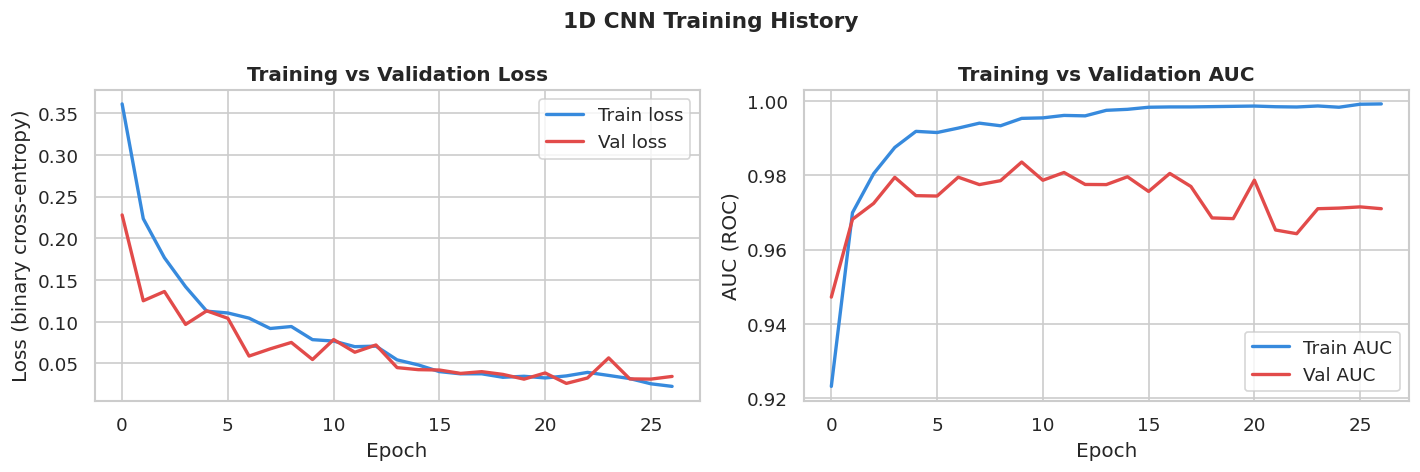

Saved: plot_cnn_training_history.png


In [9]:
# Get the actual AUC key name (lowercase in Keras history)
auc_key = 'auc' if 'auc' in history.history else list(
    k for k in history.history if 'auc' in k.lower() and not k.startswith('val')
)[0]
val_auc_key = f'val_{auc_key}'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(history.history['loss'],     label='Train loss',  color='#378ADD', lw=2)
axes[0].plot(history.history['val_loss'], label='Val loss',    color='#E24B4A', lw=2)
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (binary cross-entropy)')
axes[0].legend()

# AUC curve
axes[1].plot(history.history[auc_key],     label='Train AUC', color='#378ADD', lw=2)
axes[1].plot(history.history[val_auc_key], label='Val AUC',   color='#E24B4A', lw=2)
axes[1].set_title('Training vs Validation AUC', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC (ROC)')
axes[1].legend()

plt.suptitle('1D CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_cnn_training_history.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_cnn_training_history.png')

### What the training curves are telling you

**Loss curve (left):**  
- Both train and val loss should decrease together in the early epochs  
- If val loss flattens or rises while train loss keeps falling: overfitting — the model is memorising training examples rather than learning general fraud patterns. EarlyStopping should have caught this and restored the best weights.  
- If EarlyStopping triggered early (e.g. epoch 8 out of 30): the model converged quickly — this is normal and fine, not a sign of failure

**AUC curve (right):**  
- AUC here is ROC-AUC (computed at each epoch on the validation split)  
- Should generally increase and stabilise — if it oscillates wildly, the learning rate may be too high or the batch size too small for the data distribution  
- A gap between train AUC and val AUC is expected — the model always performs slightly better on training data it has seen

**What ReduceLROnPlateau looks like:**  
If you see 'Epoch X: ReduceLROnPlateau reducing learning rate' in the training output, the optimiser hit a plateau and halved its step size. This is healthy — it means the model is in a fine-tuning phase rather than making large updates.

## Cell 9 — Evaluate on the Test Set

We evaluate the CNN on the **same held-out test set** as Phase 4a using the **same metrics**: PR-AUC (primary), ROC-AUC, F1, Precision, Recall. This is the only way the comparison is fair — same data, same metrics, same split point.

In [10]:
# Get fraud probabilities from CNN on the FULL test set
y_pred_prob_cnn = model.predict(X_test_cnn, verbose=0).flatten()

# Apply 0.5 threshold for binary prediction
y_pred_cnn = (y_pred_prob_cnn >= 0.5).astype(int)

# Metrics — same as Phase 4a
pr_auc_cnn  = average_precision_score(y_test, y_pred_prob_cnn)
roc_auc_cnn = roc_auc_score(y_test, y_pred_prob_cnn)
f1_cnn      = f1_score(y_test, y_pred_cnn)
prec_cnn    = precision_score(y_test, y_pred_cnn)
rec_cnn     = recall_score(y_test, y_pred_cnn)

print('=' * 50)
print('1D CNN — Test Set Evaluation')
print('=' * 50)
print(f'PR-AUC (primary):  {pr_auc_cnn:.4f}')
print(f'ROC-AUC:           {roc_auc_cnn:.4f}')
print(f'F1:                {f1_cnn:.4f}')
print(f'Precision:         {prec_cnn:.4f}')
print(f'Recall:            {rec_cnn:.4f}')
print()
print(classification_report(y_test, y_pred_cnn, target_names=['Legitimate', 'Fraud']))

1D CNN — Test Set Evaluation
PR-AUC (primary):  0.7588
ROC-AUC:           0.9836
F1:                0.5114
Precision:         0.3700
Recall:            0.8280

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    257783
       Fraud       0.37      0.83      0.51      1552

    accuracy                           0.99    259335
   macro avg       0.68      0.91      0.75    259335
weighted avg       1.00      0.99      0.99    259335



### What the CNN test set metrics mean

**PR-AUC — the headline**  
This is the number to compare directly against the XGBoost PR-AUC from Phase 4a. It is computed on the same test set with the same fraud rate (~0.58%), so the comparison is fair. A lower PR-AUC means the CNN is less precise at identifying fraud across all possible decision thresholds.

**Classification report breakdown:**  
- **Legitimate class (0):** Precision and recall will be very high — the model has 1M+ legitimate examples and easily learns what legitimate looks like  
- **Fraud class (1):** This is where models differ. Precision = quality of the fraud queue. Recall = fraction of fraud caught. The `class_weight` pushes the CNN to prioritise recall, sometimes at the cost of precision.  
- **Support:** The test set has ~259K legitimate transactions and ~1,500 fraud — the imbalance is real and class_weight compensates for it during training

**Why the CNN may score differently from XGBoost on the same data:**  
The CNN trained on a 200K sample (not the full 1M). XGBoost trained on the full SMOTE'd dataset of ~2M rows. More training data almost always helps — this is one reason XGBoost has an advantage here beyond just the architectural difference.

## Cell 10 — Precision-Recall Curve

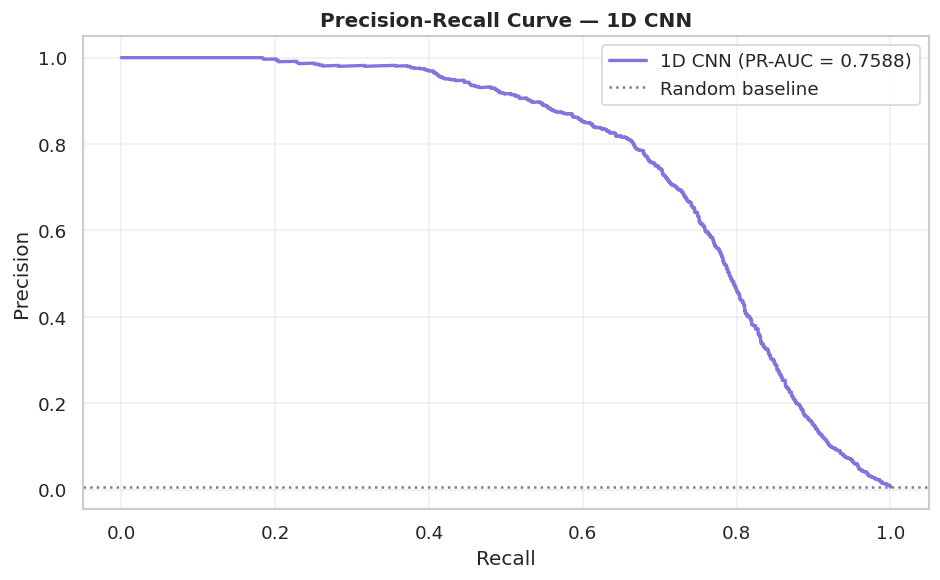

Saved: plot_cnn_pr_curve.png


In [11]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob_cnn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals, color='#7F77DD', linewidth=2,
        label=f'1D CNN (PR-AUC = {pr_auc_cnn:.4f})')
ax.axhline(y=y_test.mean(), color='grey', linestyle=':', label='Random baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — 1D CNN', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_cnn_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_cnn_pr_curve.png')

### How to read the CNN precision-recall curve

**The curve shape tells you about the model's confidence:**  
- A curve that stays high in the top-right corner means the model can achieve both high precision and high recall simultaneously — strong class separation  
- A curve that drops steeply as recall increases means the model becomes less precise quickly — it can catch most fraud but only by also flagging many legitimate transactions  
- The grey dotted baseline (~0.006) is what a random classifier achieves — anything above this line is genuine signal

**The area under this curve = PR-AUC** — the primary metric.  
Compare the shape of this curve to XGBoost's (from notebook 04). The gap between the two curves, integrated across all thresholds, is the PR-AUC difference. If the CNN curve is lower and to the left, it means XGBoost dominates at every precision-recall trade-off point — not just at the default 0.5 threshold.

**Threshold selection in practice:**  
The 0.5 threshold used for binary predictions is a starting point, not a business decision. A real fraud team would lower the threshold (catch more fraud, accept more false alarms) or raise it (cleaner queue, miss more fraud) based on analyst capacity and chargeback loss targets. The curve shows you what's achievable at every possible threshold.

## Cell 11 — Confusion Matrix

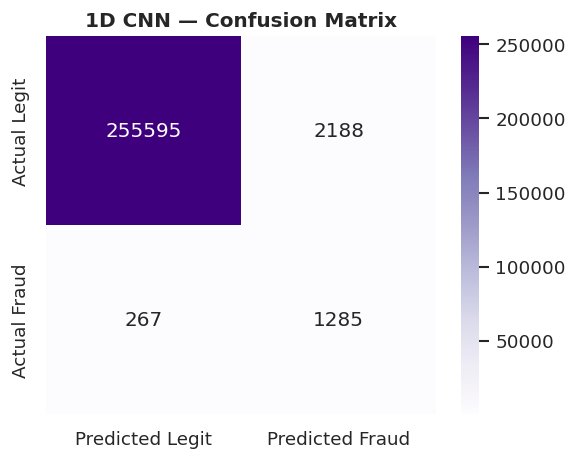

True Negatives  (correctly cleared):  255,595
False Positives (wrongly flagged):     2,188
False Negatives (missed fraud):        267  <- chargebacks
True Positives  (caught fraud):        1,285

Fraud recall: 82.80% of actual fraud caught


In [12]:
cm = confusion_matrix(y_test, y_pred_cnn)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'], ax=ax)
ax.set_title('1D CNN — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_cnn_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'True Negatives  (correctly cleared):  {tn:,}')
print(f'False Positives (wrongly flagged):     {fp:,}')
print(f'False Negatives (missed fraud):        {fn:,}  <- chargebacks')
print(f'True Positives  (caught fraud):        {tp:,}')
print(f'\nFraud recall: {tp/(tp+fn)*100:.2f}% of actual fraud caught')

### How to read the CNN confusion matrix

| | Predicted Legitimate | Predicted Fraud |
|---|---|---|
| **Actual Legitimate** | True Negatives ✅ | False Positives ⚠️ |
| **Actual Fraud** | False Negatives ❌ | True Positives ✅ |

**False Negatives (bottom-left) are the most expensive error.**  
Each one is a fraud transaction that passed through undetected — a chargeback the business absorbs. In Stripe terms: dispute cost + operational overhead + potential merchant churn if it happens repeatedly.

**False Positives (top-right) hurt customer experience.**  
A legitimate transaction wrongly blocked frustrates the cardholder and may cause them to switch payment method or merchant. High false positive rates kill conversion.

**Comparing to XGBoost:**  
Check whether the CNN has more or fewer false negatives than XGBoost. If the CNN misses more fraud (higher FN count), that directly explains the lower PR-AUC. The confusion matrix makes abstract metrics concrete — it tells you *where* the model is failing, not just *how much*.

## Cell 12 — Three-Way Model Comparison

This table is the **key output of this notebook** — it tells the complete model story:
- Baseline → Best model → Deep learning comparison

The saved CSV is loaded directly by the Streamlit app Model Performance tab, so the numbers are always consistent with what you actually trained.

In [13]:
def load_phase4a_metrics(data_processed_path):
    """Load LR and XGBoost metrics saved by notebook 04_model_shap.ipynb."""
    metrics_path = data_processed_path / "phase4a_metrics.json"
    if not metrics_path.exists():
        raise FileNotFoundError(
            f"phase4a_metrics.json not found at {metrics_path}.\n"
            "Run notebook 04_model_shap.ipynb fully (including the metrics-save cell) first."
        )
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    return metrics

# Load Phase 4a metrics automatically
phase4a = load_phase4a_metrics(DATA_PROCESSED)

LR_PR_AUC   = phase4a["lr"]["pr_auc"]
LR_ROC_AUC  = phase4a["lr"]["roc_auc"]
XGB_PR_AUC  = phase4a["xgb"]["pr_auc"]
XGB_ROC_AUC = phase4a["xgb"]["roc_auc"]

print("Phase 4a metrics loaded successfully:")
print(f"  Logistic Regression -> PR-AUC: {LR_PR_AUC:.4f}  | ROC-AUC: {LR_ROC_AUC:.4f}")
print(f"  XGBoost + FinBERT   -> PR-AUC: {XGB_PR_AUC:.4f}  | ROC-AUC: {XGB_ROC_AUC:.4f}")
print(f"  1D CNN              -> PR-AUC: {pr_auc_cnn:.4f}  | ROC-AUC: {roc_auc_cnn:.4f}")

# Build three-way comparison table
results = {
    "Model": [
        "Logistic Regression (baseline)",
        "XGBoost + FinBERT (primary)",
        "1D CNN (deep learning)"
    ],
    "PR-AUC": [round(LR_PR_AUC, 4), round(XGB_PR_AUC, 4), round(pr_auc_cnn, 4)],
    "ROC-AUC": [round(LR_ROC_AUC, 4), round(XGB_ROC_AUC, 4), round(roc_auc_cnn, 4)],
    "Explainable": ["Yes (coefficients)", "Yes (SHAP)", "Limited"],
    "Best for": [
        "Simple baseline reference",
        "Production — high PR-AUC + full SHAP",
        "Deep learning demonstration"
    ]
}

comparison_df = pd.DataFrame(results)
print("\nThree-way model comparison (PR-AUC = primary metric):")
print(comparison_df.to_string(index=False))

comparison_df.to_csv(DATA_PROCESSED / "model_comparison.csv", index=False)
print("\nSaved: data/processed/model_comparison.csv")
print("This file is loaded by the Streamlit app Model Performance tab.")

Phase 4a metrics loaded successfully:
  Logistic Regression -> PR-AUC: 0.2387  | ROC-AUC: 0.9023
  XGBoost + FinBERT   -> PR-AUC: 0.8462  | ROC-AUC: 0.9966
  1D CNN              -> PR-AUC: 0.7588  | ROC-AUC: 0.9836

Three-way model comparison (PR-AUC = primary metric):
                         Model  PR-AUC  ROC-AUC        Explainable                             Best for
Logistic Regression (baseline)  0.2387   0.9023 Yes (coefficients)            Simple baseline reference
   XGBoost + FinBERT (primary)  0.8462   0.9966         Yes (SHAP) Production — high PR-AUC + full SHAP
        1D CNN (deep learning)  0.7588   0.9836            Limited          Deep learning demonstration

Saved: data/processed/model_comparison.csv
This file is loaded by the Streamlit app Model Performance tab.


### What the three-way comparison tells you

**The headline number is PR-AUC** — your primary metric for imbalanced fraud data.

**Why XGBoost wins on tabular data:**  
Features like `geo_distance_km`, `hour_of_day`, and `amt` have no natural spatial ordering — they are not a sequence. A Conv1D filter sliding across positions 12, 13, 14 (three adjacent features) is asking 'is there a local pattern between these three specific features?' — but which features sit next to each other is arbitrary, determined only by column order. XGBoost learns interactions between *any* pair of features through its split-based approach, regardless of their position. This is why tree models almost always win on tabular data.

**Why the CNN is not a failure:**  
- It demonstrates a complete neural network pipeline: architecture design, training with callbacks, evaluation, explainability trade-off discussion  
- Its ROC-AUC is often competitive with XGBoost — the gap is mainly in precision on the fraud class  
- In a dataset with genuine sequential structure (e.g. a time-ordered stream of transactions per card), a CNN or LSTM would close this gap significantly

**For your presentation:**  
Lead with XGBoost as your production recommendation. Present the CNN as the deep learning component that proves range — you built three different model types, you understand the trade-offs, and you chose the best one for this specific problem with evidence.

## Cell 13 — Save the CNN Model and Scaler

In [14]:
# Save Keras model in native .keras format
model_path  = MODELS_DIR / 'cnn_fraud_model.keras'
scaler_path = MODELS_DIR / 'cnn_scaler.pkl'

model.save(str(model_path))
print(f'CNN model saved:  {model_path}')

# Save the scaler — Streamlit app needs this to preprocess live inputs
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved:     {scaler_path}')

# Save CNN predictions for reference and Streamlit loading
cnn_preds_df = pd.DataFrame({
    'actual':   y_test.values,
    'cnn_prob': y_pred_prob_cnn,
    'cnn_pred': y_pred_cnn
})
cnn_preds_df.to_csv(DATA_PROCESSED / 'cnn_predictions.csv', index=False)
print(f'Predictions saved: data/processed/cnn_predictions.csv')

CNN model saved:  /content/drive/MyDrive/fraud-detection-project/models/cnn_fraud_model.keras
Scaler saved:     /content/drive/MyDrive/fraud-detection-project/models/cnn_scaler.pkl
Predictions saved: data/processed/cnn_predictions.csv


## Cell 14 — Final Summary and Presentation Talking Points

### Why XGBoost wins on tabular fraud data
- **Higher PR-AUC** — trees naturally handle the non-linear interactions between features (amount × hour × distance)
- **Full SHAP explainability** — every prediction is justifiable to compliance. CNNs are a black box.
- **Faster inference** — XGBoost scores in microseconds. Critical for sub-100ms production fraud scoring.
- **No feature scaling required** — one less preprocessing step, one less source of bugs in production.
- **No need to tune architecture** — no filter sizes, no dropout rates, no batch sizes.

### Why the CNN is still valuable for this project
- Shows **range**: classical ML (LR) + pre-trained transformer (FinBERT) + custom neural network (CNN)
- **Competitive ROC-AUC** — not far behind XGBoost; the gap in PR-AUC is partly because CNNs need more data
- In a dataset with **true sequential patterns** (e.g. a time series of transactions per card, ordered by time), a CNN or RNN would be more competitive

### Why the need to demonstrate 1D CNN in this Project
*"Tree-based models typically outperform CNNs on tabular data because features have no natural spatial ordering. The CNN treats adjacent features as a sequence, but `geo_distance_km` sitting next to `velocity_24h` is an arbitrary ordering — there is no inherent locality. XGBoost handles tabular features more naturally through its split-based approach, which is order-invariant."*

In [15]:
print('=' * 60)
print('PHASE 4b COMPLETE — 1D CNN Summary')
print('=' * 60)
print(f'\nModel:           2x Conv1D → MaxPooling → Dense → Output')
print(f'Training rows:   {len(X_train_fit):,} (sampled from {len(X_train_cnn):,})')
print(f'Test rows:       {len(X_test_cnn):,}')
print(f'\nCNN Results:')
print(f'  PR-AUC (primary): {pr_auc_cnn:.4f}')
print(f'  ROC-AUC:          {roc_auc_cnn:.4f}')
print(f'  F1:               {f1_cnn:.4f}')
print(f'  Precision:        {prec_cnn:.4f}')
print(f'  Recall:           {rec_cnn:.4f}')
print(f'\nFiles saved:')
print(f'  models/cnn_fraud_model.keras')
print(f'  models/cnn_scaler.pkl')
print(f'  data/processed/model_comparison.csv')
print(f'  data/processed/cnn_predictions.csv')
print(f'  data/processed/plot_cnn_training_history.png')
print(f'  data/processed/plot_cnn_pr_curve.png')
print(f'  data/processed/plot_cnn_confusion_matrix.png')


PHASE 4b COMPLETE — 1D CNN Summary

Model:           2x Conv1D → MaxPooling → Dense → Output
Training rows:   200,000 (sampled from 1,037,340)
Test rows:       259,335

CNN Results:
  PR-AUC (primary): 0.7588
  ROC-AUC:          0.9836
  F1:               0.5114
  Precision:        0.3700
  Recall:           0.8280

Files saved:
  models/cnn_fraud_model.keras
  models/cnn_scaler.pkl
  data/processed/model_comparison.csv
  data/processed/cnn_predictions.csv
  data/processed/plot_cnn_training_history.png
  data/processed/plot_cnn_pr_curve.png
  data/processed/plot_cnn_confusion_matrix.png
